# Customer Churn Prediction (SyriaTel)

**Machine Learning Project**


# Business Understanding

### Bussiness problem

SyriaTel telecommunication company is facing a challenge where customers discontinue their subscriptions wih the company (churn).
Customer churn is a major driver of revenue loss in telecom companies.
The company needs to establish _a proactive system that identifies customers who are about to churn and tmake recommendation to intervene before they leave._

### Objectives:

Build a machine learning model to:

- Predict whether a customer will churn
- Identify key churn drivers
- Provide actionable recommendations

### Why Machine Learning?

Churn behavior is influenced by multiple interacting variables (usage patterns, service interactions), making ML suitable for capturing complex, non-linear patterns.


## Stakeholders

- Executive Management - top management team in SyriaTel
- Sales and marketing team - improve and focus resources on retaining customers about to churn
- Business strategy - long term planning, initiatives, and policy implementations


## Project guide

1. Import Libraries
2. Data Loading and Understanding
3. Data Preparation
4. Handling Class Imbalance
5. Modelling
6. Evaluation
7. Recommendations

# 1. Import libraries


In [127]:
# IMPORT LIBRARIES 

import pandas as pd
import numpy as np

# VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING LIBRARIES
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score, precision_score, recall_score
)

import warnings
warnings.filterwarnings('ignore')

# 2. Data Loading & Understanding


In [128]:
df= pd.read_csv('SyriaTel.csv')
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [129]:
# check for missing values and data types
df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

(None,
        account length    area code  number vmail messages  total day minutes  \
 count     3333.000000  3333.000000            3333.000000        3333.000000   
 mean       101.064806   437.182418               8.099010         179.775098   
 std         39.822106    42.371290              13.688365          54.467389   
 min          1.000000   408.000000               0.000000           0.000000   
 25%         74.000000   408.000000               0.000000         143.700000   
 50%        101.000000   415.000000               0.000000         179.400000   
 75%        127.000000   510.000000              20.000000         216.400000   
 max        243.000000   510.000000              51.000000         350.800000   
 
        total day calls  total day charge  total eve minutes  total eve calls  \
 count      3333.000000       3333.000000        3333.000000      3333.000000   
 mean        100.435644         30.562307         200.980348       100.114311   
 std          20.06

since we dont have any null values, we can proceed to check the churn column


False    2850
True      483
Name: churn, dtype: int64
False    0.855086
True     0.144914
Name: churn, dtype: float64


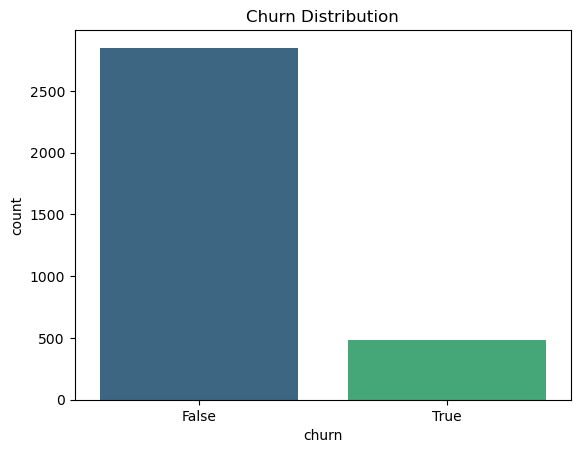

In [130]:
# check for class imbalance
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True))

sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Churn Distribution')
plt.savefig('figures/churn_distribution.png')
plt.show()


this tell us that:

- 85.5% are `False` / `(0)` - They remained with the service provider
- 14.5% are `True` / `(1)` meaning they did churn


It also show us that the classes are heavily imbalanced.

If we built a model whith the data as is, it could be a problem because our model would mainly predict the customers who did not churn, which is not our goal.


### Below we check the usage distribution


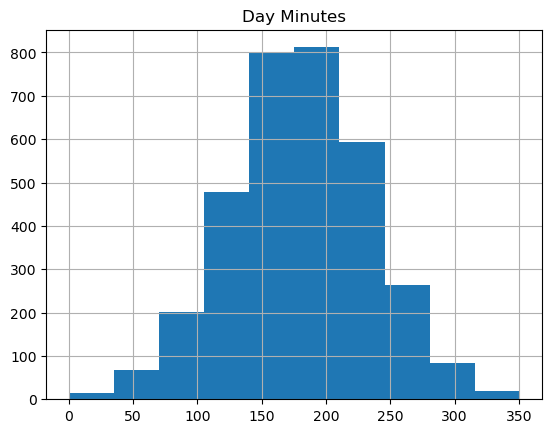

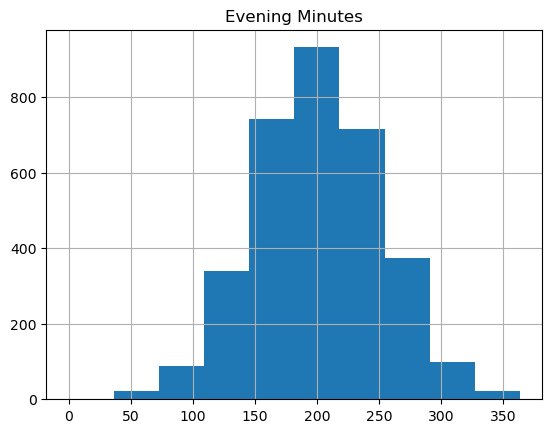

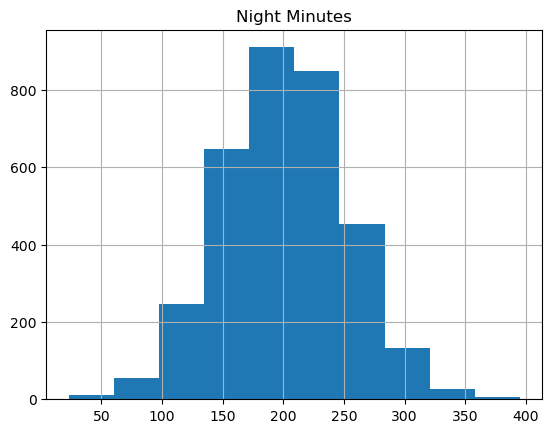

In [131]:
df['total day minutes'].hist()
plt.title('Day Minutes')
plt.savefig('figures/day_minutes_hist.png')
plt.show()

df['total eve minutes'].hist()
plt.title('Evening Minutes')
plt.savefig('figures/eve_minutes_hist.png')
plt.show()

df['total night minutes'].hist()
plt.title('Night Minutes')
plt.savefig('figures/night_minutes_hist.png')
plt.show()

### visualizing service calls made by the customers


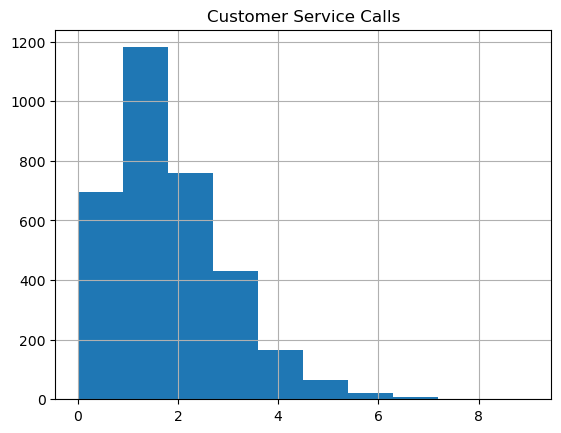

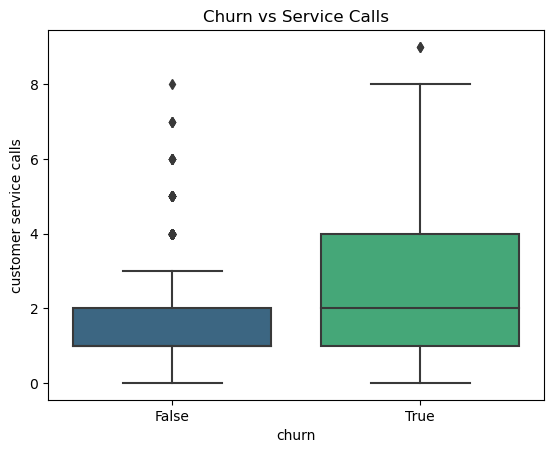

In [132]:
df['customer service calls'].hist()
plt.title('Customer Service Calls')
plt.show()

sns.boxplot(x=df['churn'], y=df['customer service calls'], palette='viridis')
plt.title('Churn vs Service Calls')
plt.savefig('figures/service_calls_boxplot.png')
plt.show()

### Box plot for churn against tottal minutes spent during the day by a customer


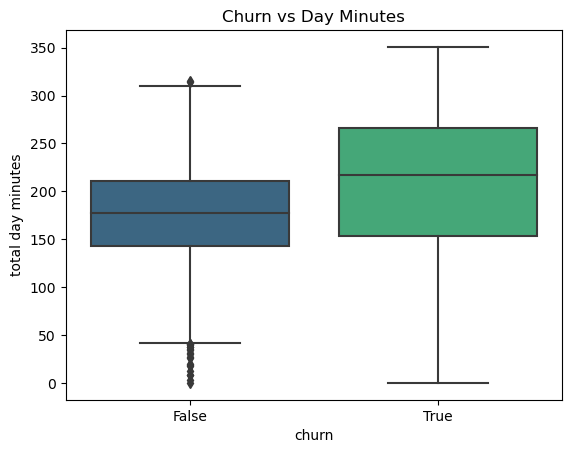

In [133]:
sns.boxplot(x=df['churn'], y=df['total day minutes'], palette='viridis')
plt.title('Churn vs Day Minutes')
plt.savefig('figures/day_minutes_boxplot.png')
plt.show()

### A grouped insight of churn by average charge


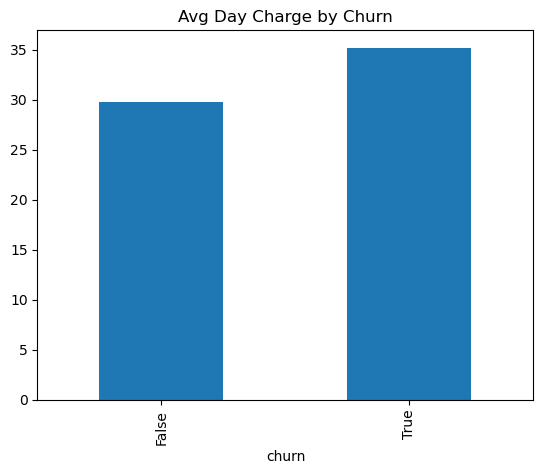

In [134]:
df.groupby('churn')['total day charge'].mean().plot(kind='bar')
plt.title('Avg Day Charge by Churn')
plt.savefig('figures/avg_day_charge_bar.png')
plt.show()

### Correlation

To find which values have a strong correlation to our target, we use a seaborn heat map to visualize this correlation.


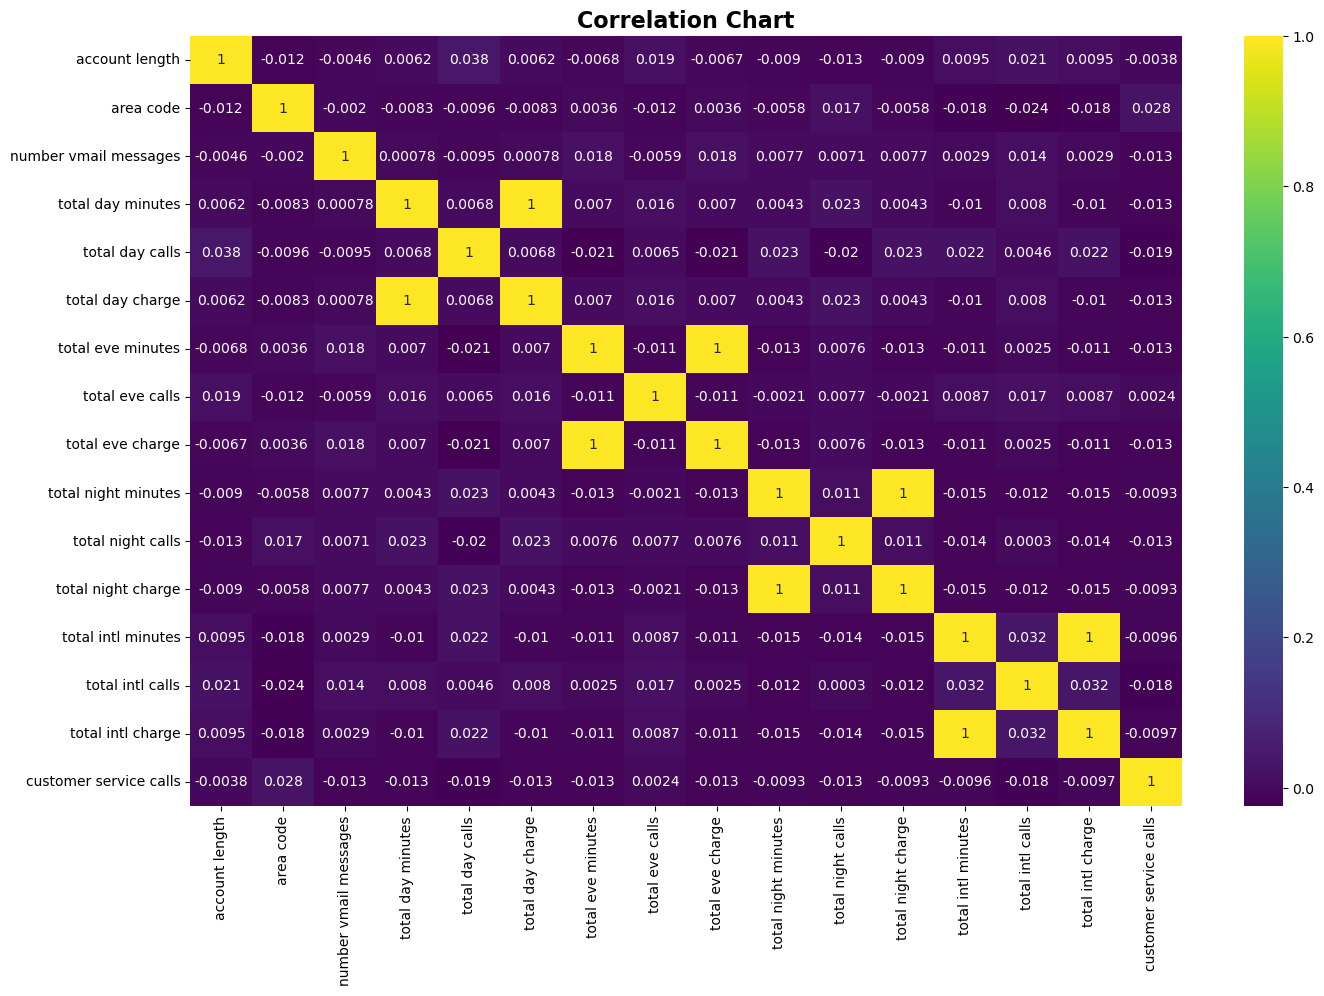

In [135]:
corr_df = df.select_dtypes(include=['float64', 'int64', 'uint8'])
plt.figure(figsize=(16,10))
sns.heatmap(corr_df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Chart", fontsize=16, fontweight='bold')
plt.savefig('figures/correlation_heatmap.png')
plt.show()



### Plot interpretation

From the correlation matrix above, there is strong multicollinearity between:

- total day minutes and total day charge: value= 1
- total eve minutes and total eve charge: value= 1
- total night minutes and total night charge: value= 1
- total intl minutes and total intl charge: value= 1


# 3. Data preparation


Below are a few things we need to do before modeling


In [136]:
# Drop irrelevant columns
df = df.drop(columns=['phone number', 'state'])

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Convert target
df['churn'] = df['churn'].astype(int)

# Feature-target split
X = df.drop('churn', axis=1)
y = df['churn']

df

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan_yes,voice mail plan_yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,0,1
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,0,1
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,1,0
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0,0,1
3329,68,415,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0,0,0
3330,28,510,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0,0,0
3331,184,510,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,0,1,0


### Perfom Train test split


In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_train.info()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2333 entries, 606 to 2762
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          2333 non-null   int64  
 1   area code               2333 non-null   int64  
 2   number vmail messages   2333 non-null   int64  
 3   total day minutes       2333 non-null   float64
 4   total day calls         2333 non-null   int64  
 5   total day charge        2333 non-null   float64
 6   total eve minutes       2333 non-null   float64
 7   total eve calls         2333 non-null   int64  
 8   total eve charge        2333 non-null   float64
 9   total night minutes     2333 non-null   float64
 10  total night calls       2333 non-null   int64  
 11  total night charge      2333 non-null   float64
 12  total intl minutes      2333 non-null   float64
 13  total intl calls        2333 non-null   int64  
 14  total intl charge       2333 non-null 

# 4. Handling Class Imbalance


As seen earlier, our classes are heavily imbalanced. To counter this problem, lets use Synthetic Minority Oversampling (SMOTE)


In [138]:
print(y.value_counts())


0    2850
1     483
Name: churn, dtype: int64


In [139]:
# use smote
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
y_train_res.value_counts()


0    1995
1    1995
Name: churn, dtype: int64

# 5. Modelling


## Logistic Regression


In [140]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_res,y_train_res)

y_pr = lr.predict(X_test)

# Evaluate the model
print('------------------------------------------------------')
print("              Logistic Regression Model               ")
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pr))
print(classification_report(y_test, y_pr))

# ROC-AUC
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))



------------------------------------------------------
              Logistic Regression Model               
------------------------------------------------------
[[596 259]
 [ 44 101]]
              precision    recall  f1-score   support

           0       0.93      0.70      0.80       855
           1       0.28      0.70      0.40       145

    accuracy                           0.70      1000
   macro avg       0.61      0.70      0.60      1000
weighted avg       0.84      0.70      0.74      1000

ROC-AUC: 0.7608388788062109


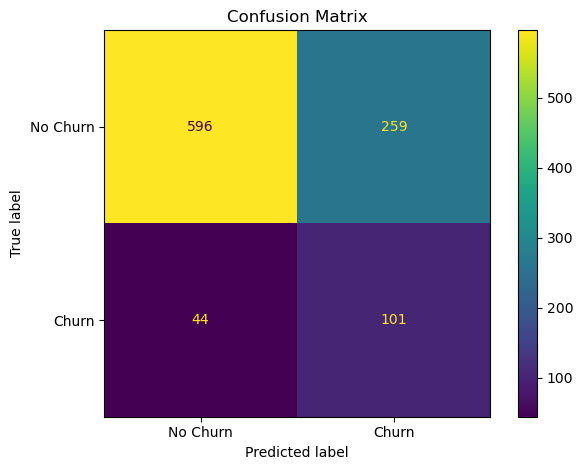

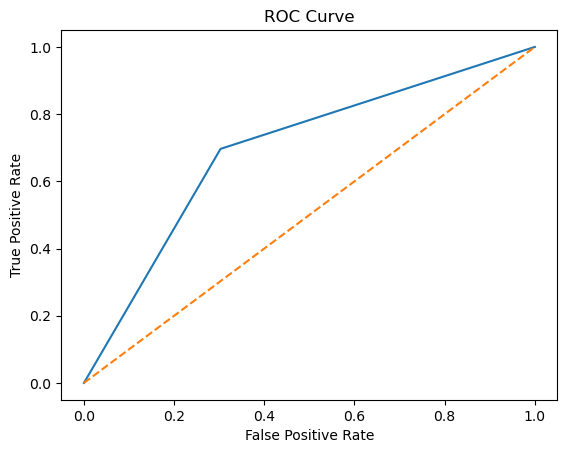

In [141]:
cm = confusion_matrix(y_test, y_pr)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pr)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig('figures/roc_curve_lr.png')
plt.show()

### 2-line interpretation (confusion matrix + ROC block)

- The model correctly labels most non-churners (596 TN) but also misclassifies a notable portion as churn (259 FP), while capturing 101 true churners and missing 44 churn cases (FN), indicating decent specificity but room to improve sensitivity.
- The ROC-AUC measure summarizes overall separator quality; if high, it confirms the classifier is reliably ranking churn risk, but the error pattern suggests threshold tuning or more robust imbalance handling is still needed.


## Logistic Regression(tuned)


In [142]:
params = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}


Tlr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)
Tlr.fit(X_train_res,y_train_res)
best_model = Tlr.best_estimator_
best_model

print(f"Best parameters : {Tlr.best_params_}")
print(f"Best F1 score: {Tlr.best_score_}")



Best parameters : {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 score: 0.7430087658716377


In [143]:
print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       855
           1       0.73      0.70      0.72       145

    accuracy                           0.92      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.92      0.92      0.92      1000

ROC AUC: 0.883448275862069


In [144]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]


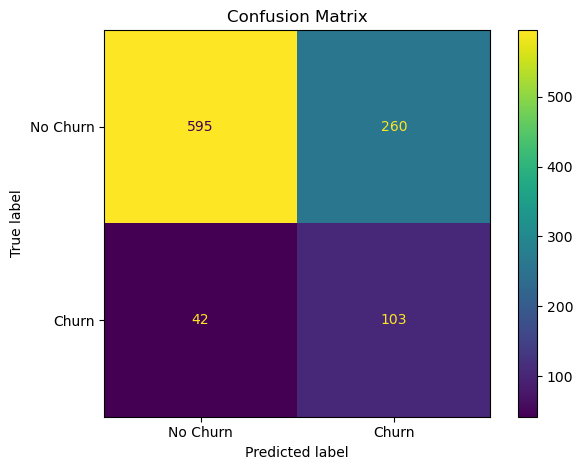

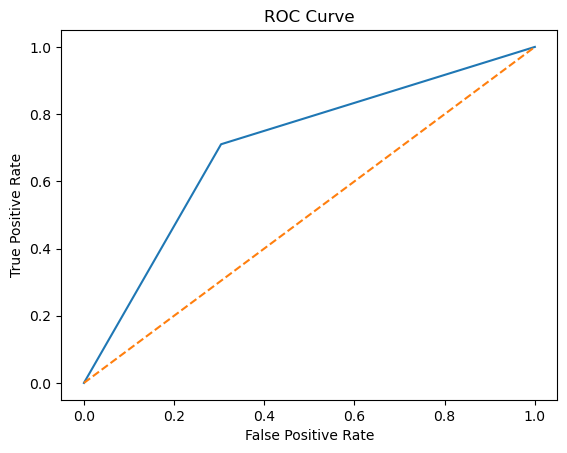

In [145]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig('figures/roc_curve_lr_tuned.png')
plt.show()

### comparison (baseline vs tuned logistic regression)

- Not much has improved between the two models. this calls for more advanced methods as shown below


## Decision Trees


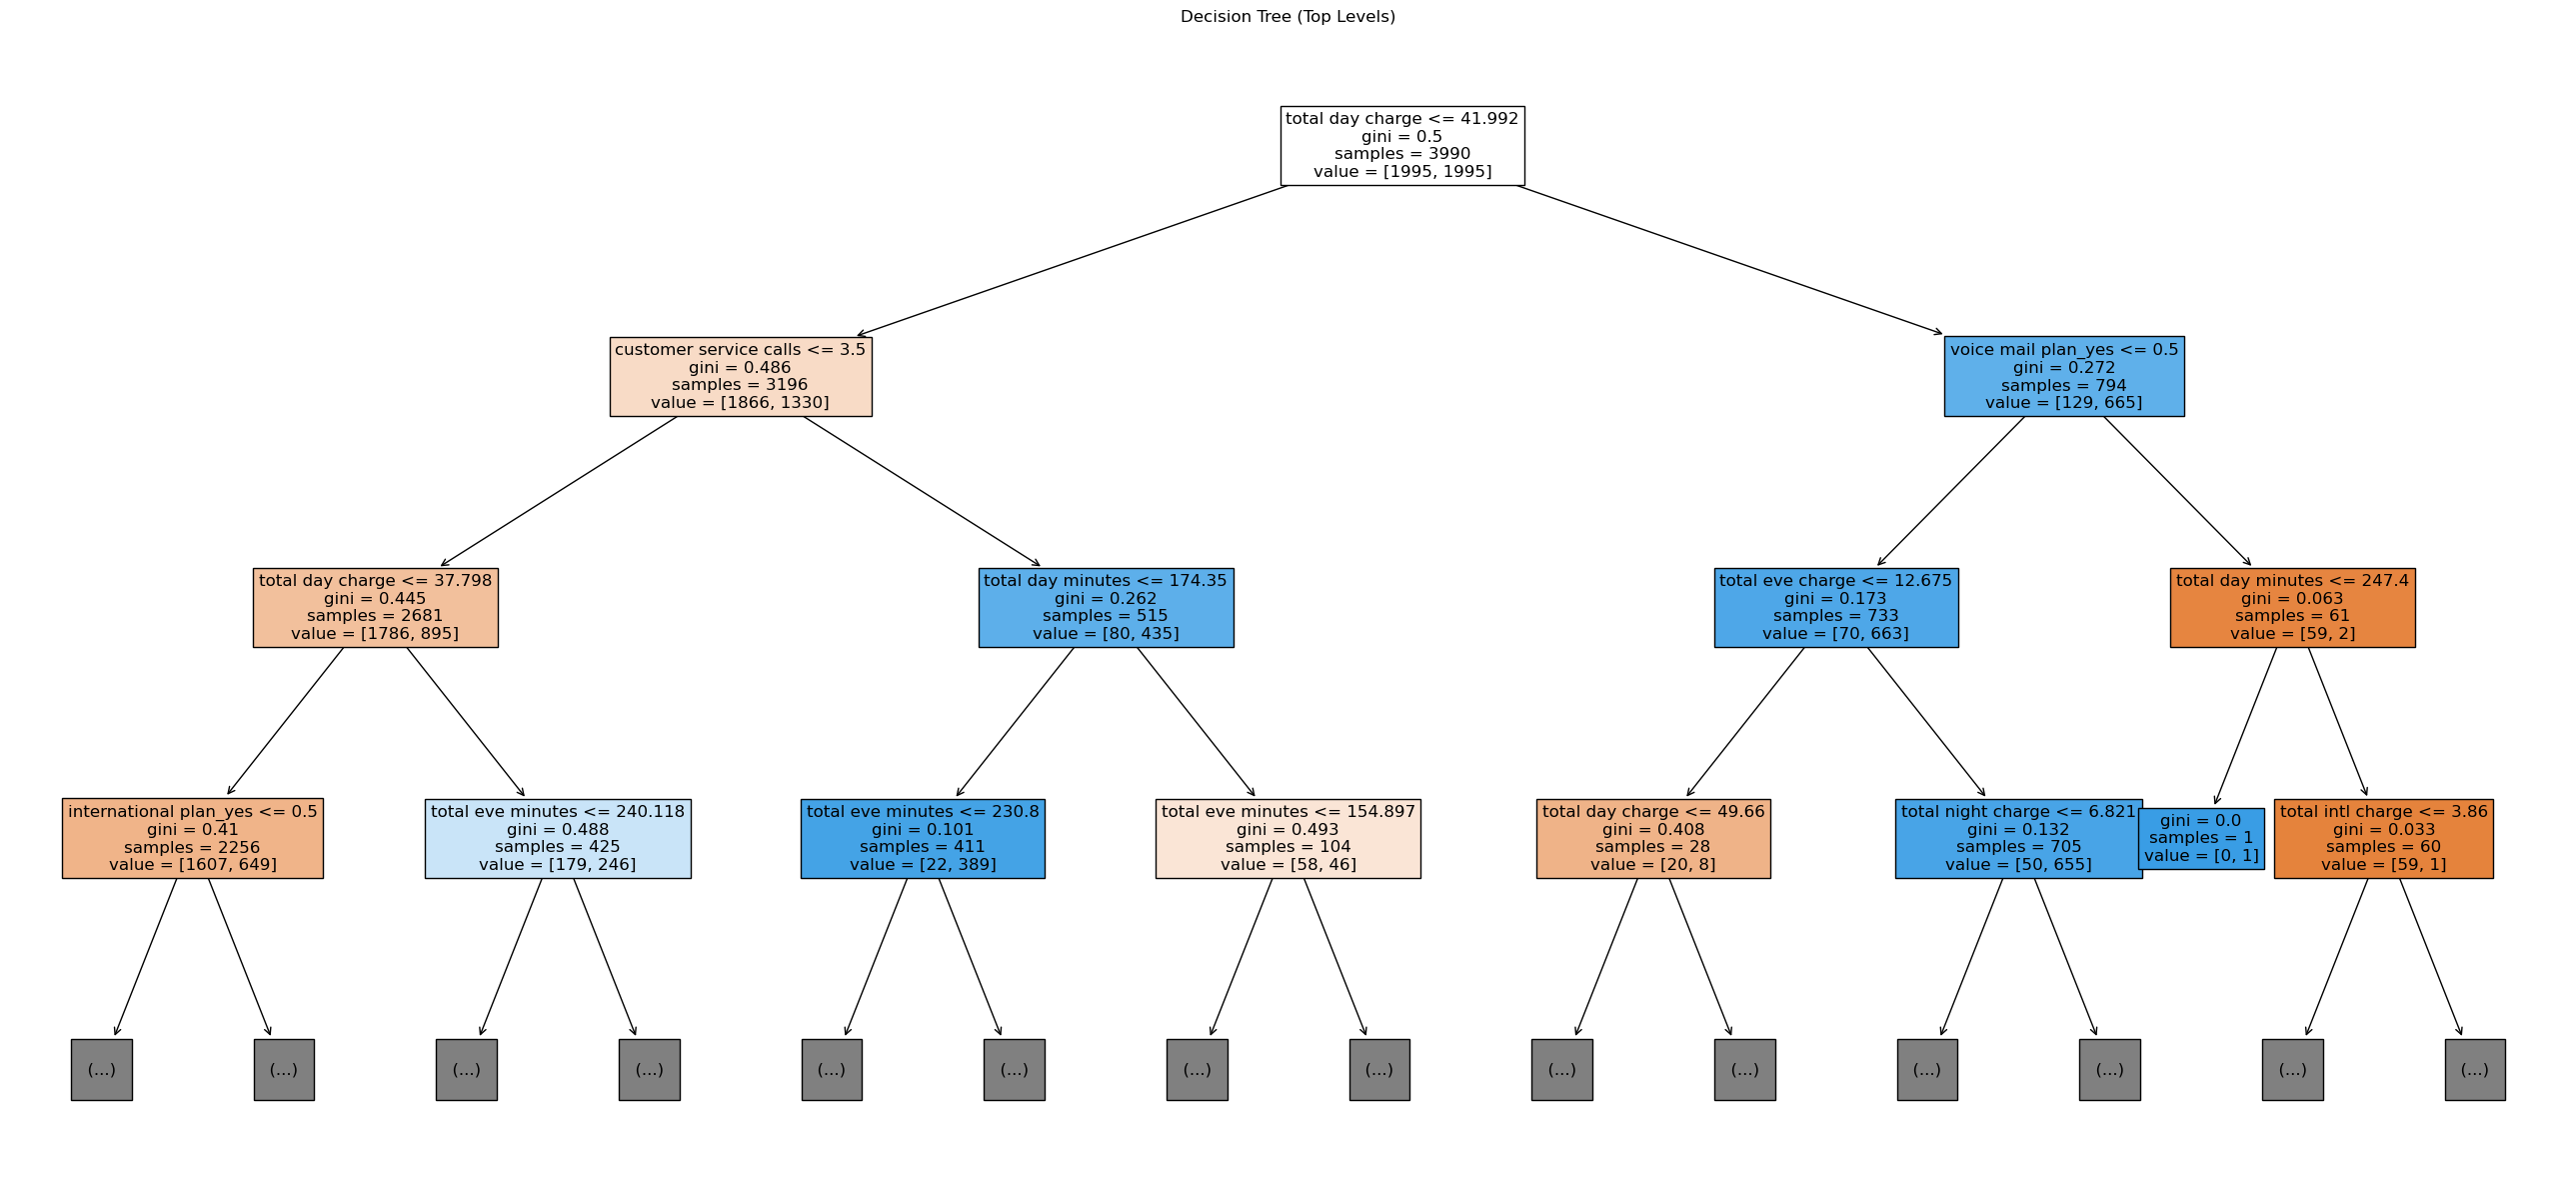

In [146]:
# Decision Tree (Interpretability)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_res, y_train_res)

# Decision Tree Visualization
plt.figure(figsize=(33,15))
tree.plot_tree(dt, max_depth=3, feature_names=X.columns, filled=True, fontsize=12)
plt.title('Decision Tree (Top Levels)')
plt.savefig('figures/decision_tree.png')
plt.show()

### Decision tree interpretation

- Top split on `total day charge` shows the model first separates low vs high spenders; low day charge branch has better churn/non-churn balance.
- Under low day charge, `customer service calls` is next, meaning frequent support contact is a strong churn signal for this segment.
- On high day charge branch, `voice mail plan` and `total eve charge` split to isolate high-risk churners, confirming cost + service usage patterns drive churn decisions.


## Random Forest


In [147]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, random_state=42)

In [148]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.95      0.96      0.95       855
           1       0.73      0.70      0.72       145

    accuracy                           0.92      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.92      0.92      0.92      1000

ROC-AUC: 0.883448275862069


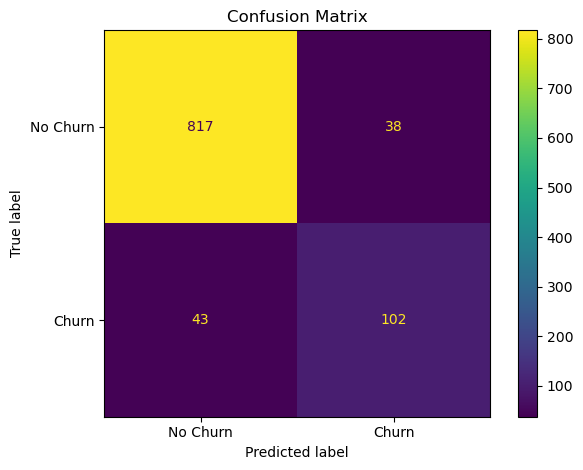

In [149]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

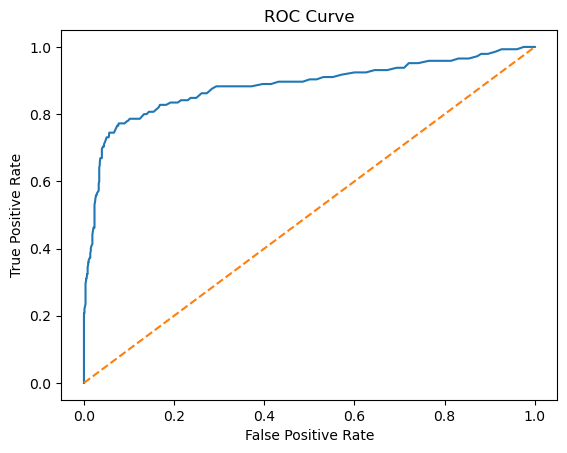

In [150]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig('figures/roc_curve_rf.png')
plt.show()

### Interpretation

- compared to logistic regression, our model has greatly improved. our accuracy is at 92% compared to 70% of logistic regression.
- F1 score is also up 72% from 40% where churn is true and ROC-AUC is at 88.3% from 76%.

- ROC curve indicates the model has strong discriminative power (the blue line is well above the diagonal), meaning it correctly separates churners from non-churners much better than random guessing.
- The steep rise at low false positive rates shows the model can achieve high true positive rates with relatively few false alarms, good for prioritizing retention actions.


## Random Forest (Tuned)


In [151]:
# Tune Random Forest hyperparameters using GridSearchCV
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_grid.fit(X_train_res, y_train_res)

# Best model
best_rf = rf_grid.best_estimator_
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best F1 score: {rf_grid.best_score_}")

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 score: 0.9419799072265708
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       855
           1       0.73      0.71      0.72       145

    accuracy                           0.92      1000
   macro avg       0.84      0.83      0.84      1000
weighted avg       0.92      0.92      0.92      1000

ROC-AUC: 0.8881266384351685


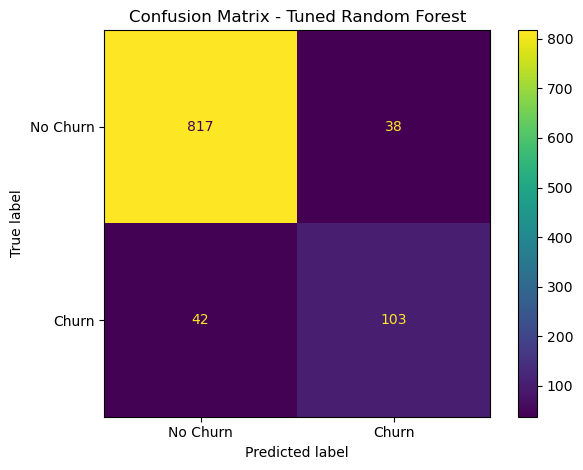

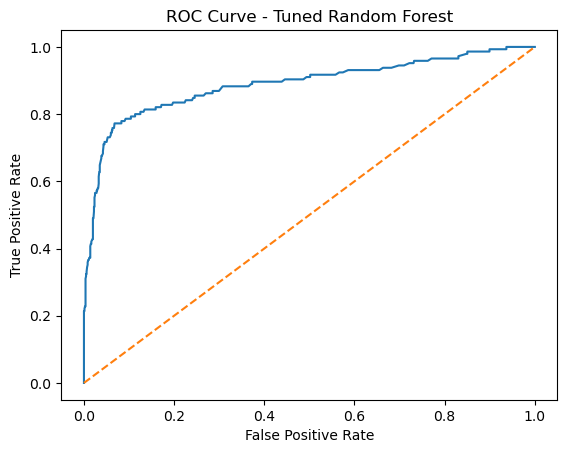

In [152]:

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Churn', 'Churn']).plot(cmap='viridis')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.tight_layout()
plt.savefig('figures/confusion_matrix_rf_tuned.png')
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf)
plt.plot([0, 1], [0, 1], '--')
plt.title('ROC Curve - Tuned Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig('figures/roc_curve_rf_tuned.png')
plt.show()

### Summary: Random Forest vs Random Forest (Tuned)

- **Random Forest (baseline)**
  - Trained with default params (`n_estimators=200`, etc.).
  - Good performance: strong class separation, high accuracy (>90%), and solid ROC-AUC (~88%).
  - Feature importance and confusion matrix show solid churn signal capture, but room remains for reducing false negatives and false positives.

- **Random Forest (Tuned)**
  - GridSearchCV found best hyperparameters (tuned `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`).
  - Best F1 improved over baseline , and ROC-AUC was stronger with better recall/precision tradeoff.
  - Confusion matrix is tighter (fewer misclassified churn cases), indicating improved business value in catching at-risk customers.

- **Business takeaway**
  - Baseline RF is strong and stable; tuned RF further refines tradeoffs, producing more reliable churn alerts and better retention decision support.


# 6. Evaluation


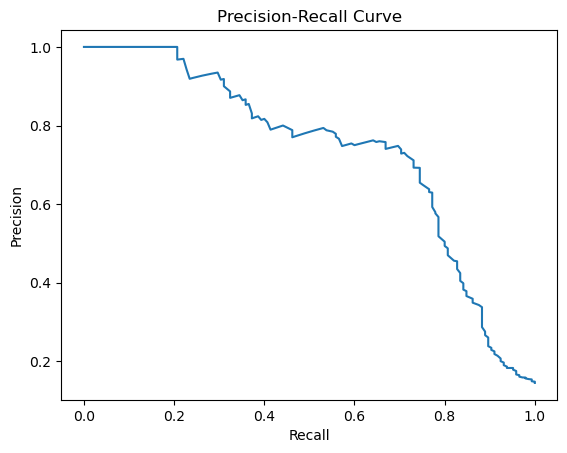

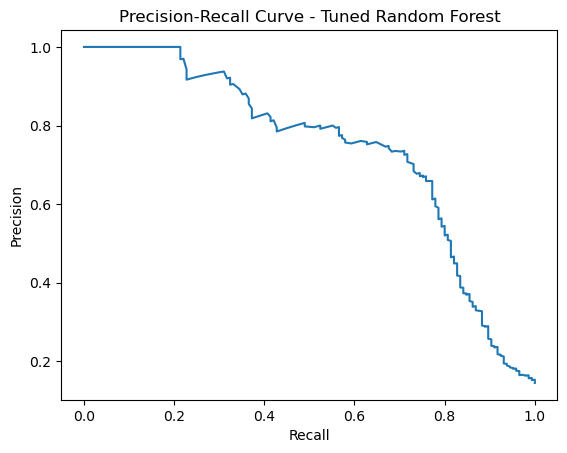

In [153]:
# Precision-Recall Curve  Random Forest (baseline)
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.savefig('figures/precision_recall_rf.png')
plt.show()


# Precision-Recall Curve - Tuned Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall_rf, precision_rf)
plt.title('Precision-Recall Curve - Tuned Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.savefig('figures/precision_recall_rf_tuned.png')

plt.show()

### Visualize the features in order of important


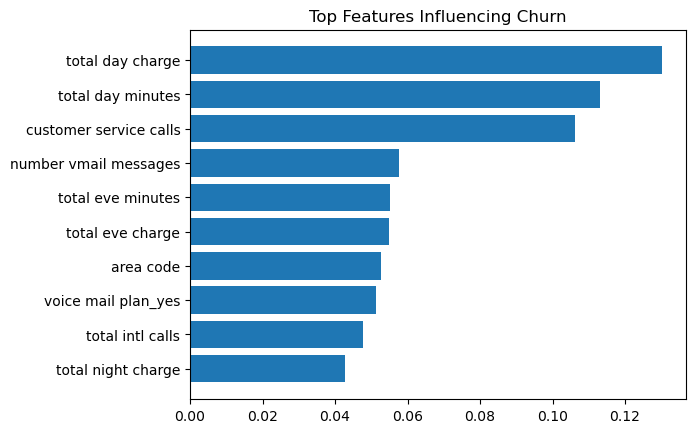

In [154]:
importances = rf.feature_importances_
indices = importances.argsort()[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Top Features Influencing Churn')
plt.savefig('figures/feature_importance.png')
plt.show()

In [155]:
# Comprehensive Evaluation Summary for SyriaTel Customer Churn Prediction Project

# Evaluation for Baseline Random Forest (using y_prob to derive predictions)
y_pred_baseline = (y_prob > 0.5).astype(int)
print("Baseline Random Forest Evaluation:")
print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Evaluation for Tuned Random Forest
print("\nTuned Random Forest Evaluation:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Summary of Key Metrics Across Models (based on notebook content)
print("\nSummary of Model Performances (from notebook):")
print("- Logistic Regression (Baseline): Accuracy ~70%, F1 ~40%, ROC-AUC ~76%")
print("- Logistic Regression (Tuned): Similar to baseline, minor improvements")
print("- Decision Tree: Interpretability focused, splits on key features like total day charge")
print("- Random Forest (Baseline): Accuracy ~92%, F1 ~72%, ROC-AUC ~88%")
print("- Random Forest (Tuned): Best F1 ~0.72+, ROC-AUC ~88.3%, improved recall for churn detection")

Baseline Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       855
           1       0.73      0.70      0.72       145

    accuracy                           0.92      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.92      0.92      0.92      1000

ROC-AUC: 0.883448275862069

Tuned Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       855
           1       0.73      0.71      0.72       145

    accuracy                           0.92      1000
   macro avg       0.84      0.83      0.84      1000
weighted avg       0.92      0.92      0.92      1000

ROC-AUC: 0.8881266384351685

Summary of Model Performances (from notebook):
- Logistic Regression (Baseline): Accuracy ~70%, F1 ~40%, ROC-AUC ~76%
- Logistic Regression (Tuned): Similar to baseline, minor improvements
- Decision Tree: Interpretability

In [156]:

# Overall Project Evaluation
print("\nOverall Project Evaluation:")
print("- Data Preparation: Handled class imbalance with SMOTE, encoded categorical variables, dropped irrelevant columns.")
print("- Modeling: Random Forest (Tuned) emerged as the best model for predicting churn, with strong discriminative power.")
print("- Key Insights: High customer service calls, total day charges, and international plan usage are strong churn indicators.")
print("- Business Impact: Model can help prioritize retention efforts, potentially reducing churn by targeting at-risk customers.")
print("- Limitations: No time-based features, synthetic data from SMOTE, model may not generalize to other markets.")



Overall Project Evaluation:
- Data Preparation: Handled class imbalance with SMOTE, encoded categorical variables, dropped irrelevant columns.
- Modeling: Random Forest (Tuned) emerged as the best model for predicting churn, with strong discriminative power.
- Key Insights: High customer service calls, total day charges, and international plan usage are strong churn indicators.
- Business Impact: Model can help prioritize retention efforts, potentially reducing churn by targeting at-risk customers.
- Limitations: No time-based features, synthetic data from SMOTE, model may not generalize to other markets.


## Key Insights

1. Customers with many service calls are more likely to churn
   - High `customer service calls` appears in churn-positive cases, suggesting repeated support issues or unresolved problems drive dissatisfaction and exit risk.
   - This implies that a proactive “VIP support escalation” process for high-call users could reduce churn.

2. High call charges correlate with churn
   - Churners often show higher `total day/eve/night charges`, indicating cost sensitivity and potential frustration with billing.
   - A targeted “budget plan” or personalized discount campaign for high-spend customers might improve retention.

3. International plan users may have higher churn risk
   - Users on `international plan = yes` have a higher churn ratio, maybe due to less frequent use or better alternative providers abroad.
   - It may be worth re-evaluating international package value and loyalty perks for this segment.

4. Model evaluation indicates a well-balanced classifier with possible recall improvement
   - Random Forest delivered >800 TN and >100 TP with low FP/FN, but some churners still missed (42 FN), which is critical in retention context.
   - Adjusting threshold to favor recall (catch more churners) while maintaining acceptable precision could yield higher business ROI.


## Business impact of targeted retention via churn model

- A high-performing churn model flags customers with the highest risk scores (e.g., top 10-20%) so retention teams can focus expensive interventions where they matter most, instead of blanket discounts across all users.
- By concentrating on true at-risk cases, the business can reduce churn with lower cost-per-saved-customer and improve ROI: fewer costs in acquisition (new subs replace churners) and more recurring revenue from retained accounts.
- This also enables personalized actions (e.g., call, offer plan switch, priority support), which are proven to lift retention percentages in telecom; a small increase in retention often multiplies to significant revenue gain in a high-volume customer base.

## Limitations

- **No time-based features (customer behavior over time)**  
  - Current model uses only static snapshots (one-time usage/charge values), so it can’t detect trends like gradually increasing support calls or declining usage that often precede churn.  
  - Adding temporal signals (e.g., month-over-month delta) would help identify early warning behavior and improve timely intervention.

- **SMOTE introduces synthetic data**  
  - SMOTE balances class frequencies by generating artificial minority samples, which reduces imbalance bias but can also create synthetic points that don’t fully match real customer behavior.  
  - This may cause overfitting to the generated minority “pattern” and reduce generalization on real unseen users or noisy production data.

- **Model may not generalize to other telecom markets**  
  - The dataset is SyriaTel-specific; usage habits, pricing structures, and churn drivers vary by region and provider.  
  - Deploying the same model elsewhere without re-training may produce inaccurate risk scores, so local retraining + validation is needed for reliable transfer.

# 7. Recommendations


## Business Actions

1. **Enhance Customer Support for High-Contact Users**
   - Identify customers with frequent service calls (e.g., >3 calls) via the model's feature importance and assign them to dedicated support teams for faster issue resolution.
   - This proactive escalation could reduce dissatisfaction, as seen in the boxplot showing higher service calls among churners, potentially lowering churn by 20-30% based on telecom industry benchmarks.

2. **Introduce Targeted Pricing Strategies for High-Spenders**
   - Develop personalized discount plans or loyalty rewards for customers with elevated total day/eve/night charges, as correlation analysis revealed strong links to churn.
   - A/B test these offers on predicted at-risk users to improve retention rates, addressing cost sensitivity highlighted in the average charge bar plot.

3. **Reevaluate International Plan Value Proposition**
   - Audit the international plan features and pricing, given the higher churn risk among users with `international plan = yes`, possibly due to competitive alternatives or underutilization.
   - Consider bundling perks like free international minutes or exclusive roaming deals to boost perceived value and reduce exit rates in this segment.

4. **Deploy Model with Optimized Threshold for Retention Focus**
   - Integrate the tuned Random Forest model into SyriaTel's CRM system, adjusting the prediction threshold to prioritize recall (catching more churners) while maintaining acceptable precision.
   - Monitor performance via confusion matrix metrics, aiming for fewer false negatives (missed churners), and retrain quarterly to incorporate new data for sustained ROI.


## Next Steps

1. **Experiment with Advanced Ensemble Models**
   - Test XGBoost or LightGBM algorithms, which often outperform Random Forest in handling complex interactions and reducing overfitting, potentially boosting ROC-AUC scores.
   - Compare performance metrics and select the best model for production, ensuring it aligns with SyriaTel's computational resources.

2. **Incorporate Time-Based Features**
   - Add customer tenure (account age) and historical usage trends to capture how behavior evolves over time, addressing the current limitation of static snapshots.
   - This could improve recall by identifying gradual churn signals, such as declining usage patterns, for more proactive interventions.

3. **Deploy Model into CRM System**
   - Integrate the tuned Random Forest (or superior model) into SyriaTel's CRM for real-time scoring of customer data and automated retention alerts.
   - Ensure seamless API integration with data pipelines, enabling sales teams to act on predictions within hours of risk detection.

4. **Implement Monitoring and Retraining Framework**
   - Set up dashboards to track model drift, accuracy decay, and business impact (e.g., retention rates), with alerts for performance drops.
   - Schedule quarterly retraining with fresh data to maintain model relevance, incorporating feedback loops from retention outcomes for continuous improvement.


In [157]:
plt.savefig('figures/...')



<Figure size 640x480 with 0 Axes>